# 🔍 RAG Retrieval Evaluation

Comprehensive evaluation of retrieval performance with popularity bias analysis.

---

## 📋 Prerequisites

Run `rag_indexing.ipynb` first to create the index.

---

## 🎯 Evaluation Pipeline

1. **Load Data** - Questions from popularity-enriched QA datasets
2. **Run Retrieval** - Retrieve documents and compute core metrics
3. **Analyze Performance** - Recall@K, MRR, ranking metrics
4. **Bias Analysis** - Popularity bias and fairness metrics
5. **Visualizations** - Comprehensive visual analysis

---

## 📊 Key Metrics

- **Recall@K** - Percentage of questions where correct document is in top K
- **MRR** (Mean Reciprocal Rank) - Average of 1/rank for all questions
- **Popularity Bias** - Preference for popular documents over correct ones
- **Decile Analysis** - Performance breakdown by popularity bins

## 1️⃣ Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset
from typing import Dict, List

from config import DATA_DIR, CACHE_DIR
from rag.native_rag_service import nativeRagService, IndexingConfig

# Evaluation Configuration
TOP_K = 10
K_VALUES = [1, 3, 5, 10, 15, 20, 25, 30]
MAX_K = max(K_VALUES)

# Collection & Index
COLLECTION_NAME = "wiki_180k_balanced_qa_500"
INDEX_DIR = Path(DATA_DIR) / COLLECTION_NAME / "index"
PATH_TO_QA_DATA = Path(DATA_DIR) / COLLECTION_NAME / "train_questions.parquet"

# Embedding Configuration (must match indexing)
CHUNK_SIZE = 4000
CHUNK_OVERLAP = 200
EMBEDDING_PROVIDER = "huggingface"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

print("✓ Configuration loaded")

/Users/cyro/Documents/VSC/PopularityBias/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✓ Configuration loaded


## 2️⃣ Load Data & Index

In [2]:
# Load questions
print(f"Loading questions from {PATH_TO_QA_DATA}")
qa_df = pd.read_parquet(PATH_TO_QA_DATA)

# Safely drop rows without questions
initial_len = len(qa_df)
if len(qa_df) < initial_len:
    print(f"⚠️ Dropped {initial_len - len(qa_df)} rows with missing invalid question text")

# Normalize Wikipedia IDs to string format for matching
qa_df['wikipedia_id'] = qa_df['wikipedia_id'].astype(str).str.strip()

print(f"✓ Loaded {len(qa_df):,} questions")

if 'dataset' in qa_df.columns:
    print(f"  📚 Datasets: {qa_df['dataset'].value_counts().to_dict()}")
    
if 'is_synthetic' in qa_df.columns:
    n_synthetic = int(qa_df['is_synthetic'].sum())
    n_real = len(qa_df) - n_synthetic
    print(f"  🤖 Real: {n_real:,} | Synthetic: {n_synthetic:,}")

# Display sample
sample = qa_df.iloc[0]
print(f"\n  Sample: {sample['question_text'][:80]}...")
print(f"  Answer: {sample['answer_texts'][0]}")
print(f"  Wiki ID: {sample['wikipedia_id']}")

Loading questions from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_180k_balanced_qa_500/train_questions.parquet
✓ Loaded 5,904 questions
  📚 Datasets: {'popqa': 3038, 'triviaqa': 1038, 'natural_questions': 988, 'synthetic': 840}
  🤖 Real: 5,064 | Synthetic: 840

  Sample: What is the capital of canton of Mirambeau?...
  Answer: Mirambeau
  Wiki ID: 10431292


In [3]:
# Load RAG index
print(f"Loading index from {INDEX_DIR}")
service = nativeRagService(IndexingConfig(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    embedding_provider=EMBEDDING_PROVIDER,
    embedding_model=EMBEDDING_MODEL,
))

index = service.load_index(output_dir=INDEX_DIR, collection_name=COLLECTION_NAME)
if index is None:
    raise RuntimeError(f"Index not found at {INDEX_DIR}. Run rag_indexing.ipynb first.")

num_chunks = index._collection.count()
print(f"✓ Loaded index with {num_chunks:,} chunks")

Loading index from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_180k_balanced_qa_500/index


Use pytorch device_name: mps
Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
Loaded index with cosine distance


✓ Loaded index with 613,848 chunks


In [4]:
# Load corpus popularity for decile calculation
print(f"Loading corpus popularity distribution")
pop_ds = load_dataset("Cyro1/enwiki_pageviews_m", split="train+test", cache_dir=CACHE_DIR)

corpus_pops = []
for i in tqdm(range(0, len(pop_ds), 100_000), desc="Extracting popularity"):
    corpus_pops.extend(pop_ds[i : i + 100_000]["popularity_avg"])

_, corpus_bin_edges = pd.qcut(pd.Series(corpus_pops), q=10, retbins=True, duplicates='drop')
print(f"✓ Loaded {len(corpus_pops):,} popularity scores and computed deciles")

Loading corpus popularity distribution


Extracting popularity: 100%|██████████| 60/60 [00:05<00:00, 11.69it/s]


✓ Loaded 5,903,530 popularity scores and computed deciles


## 3️⃣ Run Evaluation

In [5]:
print(f"\n{'='*70}")
print(f"Running Evaluation on {len(qa_df):,} questions")
print(f"{'='*70}")

# 1. Retrieve top-k for each metric (no evaluation in service)
results_df = service.retrieve_topk_by_metric(
    index=index,
    questions=qa_df["question_text"].tolist(),
    expected_ids=qa_df["wikipedia_id"].astype(str).tolist(),
    top_k=MAX_K,
    metrics=["cosine"],
    batch_size=64
)

# 2. Merge Metadata (Popularity, Origin, etc.)
meta_df = qa_df.copy()
meta_df = meta_df.rename(columns={"question_text": "question", "popularity_avg": "popularity"})
join_cols = ["question", "wikipedia_id"]

results_df = results_df.merge(
    meta_df[[c for c in meta_df.columns if c in ["popularity", "is_synthetic", "dataset", "wikipedia_title"] + join_cols]],
    on=join_cols,
    how="left"
)

# 3. Compute evaluation fields from top-k

def _compute_eval(row):
    topk_ids = row.get("topk_ids") or []
    topk_scores = row.get("topk_scores") or []
    topk_pops = row.get("topk_popularities") or []
    expected = row.get("wikipedia_id", "")

    found_at_rank = None
    correct_score = None
    wrong_pops = []

    for idx, doc_id in enumerate(topk_ids, 1):
        if doc_id == expected and found_at_rank is None:
            found_at_rank = idx
            if idx - 1 < len(topk_scores):
                correct_score = topk_scores[idx - 1]
        else:
            if idx - 1 < len(topk_pops):
                pop = topk_pops[idx - 1]
                if pop is not None:
                    wrong_pops.append(pop)

    return pd.Series({
        "found_at_rank": found_at_rank,
        "correct_doc_score": correct_score,
        "wrong_docs_popularities": wrong_pops,
    })

results_df = pd.concat([results_df, results_df.apply(_compute_eval, axis=1)], axis=1)

# 4. Add Popularity Deciles
results_df['pop_decile'] = pd.cut(
    results_df['popularity'].fillna(0),
    bins=corpus_bin_edges,
    labels=False,
    include_lowest=True
).fillna(0).astype(int)

print(f"✓ Results computed: {len(results_df):,} rows (metrics: {results_df['metric'].unique()})")
print(results_df[["metric", "found_at_rank"]].groupby("metric").describe())


Running Evaluation on 5,904 questions


Evaluating (cosine): 100%|██████████| 93/93 [01:20<00:00,  1.16batch/s]


✓ Results computed: 5,932 rows (metrics: ['cosine'])
       found_at_rank                                              
               count      mean       std  min  25%  50%  75%   max
metric                                                            
cosine        4048.0  2.476038  4.030084  1.0  1.0  1.0  2.0  30.0


## 3.5️⃣ Sample Retrievals by Popularity Decile

Quick spot-checks of questions from different popularity deciles with their top-k retrievals.

In [6]:
# Sample a few questions per popularity decile and show top-k previews
SAMPLES_PER_DECILE = 2
TOPK_PREVIEW = 5

sample_df = results_df.copy()

# Shorten long questions for readability
if "question" in sample_df.columns:
    sample_df["question"] = sample_df["question"].astype(str).map(
        lambda s: s if len(s) <= 120 else s[:119] + "…"
    )

# Build a compact top-k preview
if "topk_ids" in sample_df.columns:
    def _topk_preview(row, k=TOPK_PREVIEW):
        ids = row.get("topk_ids") or []
        scores = row.get("topk_scores") or []
        pops = row.get("topk_popularities") or []
        out = []
        for i in range(min(k, len(ids))):
            out.append({
                "id": ids[i],
                "score": scores[i] if i < len(scores) else None,
                "pop": pops[i] if i < len(pops) else None,
            })
        return out

    sample_df["topk_preview"] = sample_df.apply(_topk_preview, axis=1)

# Sample per decile (include low-frequency deciles safely)
if "pop_decile" in sample_df.columns:
    sampled = (
        sample_df
        .groupby("pop_decile", group_keys=False)
        .apply(lambda df: df.sample(n=min(SAMPLES_PER_DECILE, len(df)), random_state=42))
        .sort_values(["pop_decile", "found_at_rank"], na_position="last")
    )
else:
    sampled = sample_df.sample(n=min(10, len(sample_df)), random_state=42)

cols = [
    c for c in [
        "question",
        "wikipedia_id",
        "popularity",
        "pop_decile",
        "found_at_rank",
        "topk_preview",
    ]
    if c in sampled.columns
]

sampled[cols]

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_75718/964315517.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df


,question,wikipedia_id,popularity,pop_decile,found_at_rank,topk_preview
110,What sport does VOKO-Irodion play?,29151958,7.083333,0,1.0,"[{'id': '29151958', 'score': 0.0, 'pop': 7.083..."
419,Where does Cingulina archimedea occur geograph...,34379151,4.420833,0,NaN,"[{'id': '7819', 'score': 0.0, 'pop': 45936.083..."
889,When was the Wilson-Courtney House added to th...,50154039,12.729167,1,1.0,"[{'id': '50154039', 'score': 0.0, 'pop': 12.72..."
710,In what country is Saint-Antonin?,15738695,9.312500,1,NaN,"[{'id': '318621', 'score': 0.0, 'pop': 130672...."
1373,What sport does Shahrul Azhar Ture play?,33700463,21.062500,2,1.0,"[{'id': '33700463', 'score': 0.0, 'pop': 21.06..."
1474,Who is the author of Responsibility?,4358028,24.102273,2,NaN,"[{'id': '33659978', 'score': 0.0, 'pop': 1867...."
2278,Who was the director of Flame?,23666447,37.916667,3,1.0,"[{'id': '23666447', 'score': 0.0, 'pop': 37.91..."
1995,What genre is Theatre?,31803477,35.020833,3,NaN,"[{'id': '23477542', 'score': 0.0, 'pop': 11321..."
2421,What sport does Nobuhiro Ishizaki play?,26614439,46.083333,4,NaN,"[{'id': '55595655', 'score': 0.0, 'pop': 4.8},..."
2322,In what country is Cathedral Peak?,39733414,62.166667,4,NaN,"[{'id': '1824495', 'score': 0.0, 'pop': 3105.1..."


## 4️⃣ Compute Metrics

In [7]:
# Calculate aggregate metrics
metrics = {}

# Recall@K for all K values
for k in K_VALUES:
    recall_k = ((results_df['found_at_rank'].notna()) & 
               (results_df['found_at_rank'] <= k)).sum() / len(results_df)
    metrics[f'recall@{k}'] = recall_k

# Mean Reciprocal Rank (MRR)
reciprocal_ranks = results_df['found_at_rank'].apply(
    lambda x: 1/x if pd.notna(x) else 0
)
metrics['mrr'] = reciprocal_ranks.mean()

# Median and mean rank (for found documents only)
found_df = results_df[results_df['found_at_rank'].notna()]
metrics['median_rank'] = found_df['found_at_rank'].median() if len(found_df) > 0 else 0
metrics['mean_rank'] = found_df['found_at_rank'].mean() if len(found_df) > 0 else 0

# Success rate by dataset
if 'dataset' in results_df.columns:
    dataset_recall = results_df.groupby('dataset').apply(
        lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean()
    )
    metrics['recall_by_dataset'] = dataset_recall.to_dict()

# Success rate by synthetic status
if 'is_synthetic' in results_df.columns:
    synthetic_recall = results_df.groupby('is_synthetic').apply(
        lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean()
    )
    metrics['recall_by_synthetic'] = synthetic_recall.to_dict()

# Per-decile metrics
decile_metrics = []
for decile in range(10):
    decile_df = results_df[results_df['pop_decile'] == decile]
    if len(decile_df) == 0:
        continue
        
    decile_info = {
        'decile': decile + 1,
        'count': len(decile_df),
        'count_synthetic': int(decile_df.get('is_synthetic', pd.Series([False]*len(decile_df))).sum()),
    }
    
    # Recall@K for this decile
    for k in [1, 5, 10, 20]:
        recall = ((decile_df['found_at_rank'].notna()) & 
                 (decile_df['found_at_rank'] <= k)).sum() / len(decile_df)
        decile_info[f'recall@{k}'] = recall
    
    # MRR for this decile
    rr = decile_df['found_at_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
    decile_info['mrr'] = rr.mean()
    
    decile_metrics.append(decile_info)

decile_metrics = pd.DataFrame(decile_metrics)

print("✓ Metrics computed")

✓ Metrics computed


/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_75718/1402720586.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset_recall = results_df.groupby('dataset').apply(
/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_75718/1402720586.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  synthetic_recall = results_df.groupby('is_synthetic').apply(


## 5️⃣ Display Results

In [8]:
print("\n" + "="*70)
print("📊 OVERALL PERFORMANCE")
print("="*70)

for k in K_VALUES:
    print(f"Recall@{k:2d}: {metrics[f'recall@{k}']:6.2%}")
    
print(f"\nMRR:         {metrics['mrr']:.4f}")
if metrics.get('median_rank') is not None:
    print(f"Median Rank: {metrics['median_rank']:.1f}")
if metrics.get('mean_rank') is not None:
    print(f"Mean Rank:   {metrics['mean_rank']:.2f}")

if 'recall_by_dataset' in metrics:
    print(f"\n" + "="*70)
    print(f"📚 RECALL@{TOP_K} BY DATASET")
    print("="*70)
    for dataset, recall in metrics['recall_by_dataset'].items():
        print(f"{dataset:20s}: {recall:6.2%}")

if 'recall_by_synthetic' in metrics:
    print(f"\n" + "="*70)
    print(f"🤖 RECALL@{TOP_K} BY ORIGIN")
    print("="*70)
    for is_synth, recall in metrics['recall_by_synthetic'].items():
        origin = "Synthetic" if is_synth else "Real"
        print(f"{origin:20s}: {recall:6.2%}")

print(f"\n" + "="*70)
print(f"📈 PERFORMANCE BY POPULARITY DECILE")
print("="*70)
print(f"{'Decile':<8} {'Count':<8} {'Synth':<8} {'R@1':<8} {'R@5':<8} {'R@10':<8} {'MRR':<8}")
print("-" * 70)
for _, row in decile_metrics.iterrows():
    print(f"{int(row['decile']):<8} "
          f"{int(row['count']):<8} "
          f"{int(row['count_synthetic']):<8} "
          f"{row['recall@1']:<7.2%} "
          f"{row['recall@5']:<7.2%} "
          f"{row['recall@10']:<7.2%} "
          f"{row['mrr']:<7.4f}")

# Question distribution by decile
print(f"\n" + "="*70)
print(f"📊 QUESTION DISTRIBUTION BY DECILE")
print("="*70)
q_dist = results_df['pop_decile'].value_counts().sort_index()
for decile in range(10):
    count = q_dist.get(decile, 0)
    if count > 0:
        pct = count / len(results_df) * 100
        decile_df = results_df[results_df['pop_decile'] == decile]
        synth = int(decile_df.get('is_synthetic', pd.Series([False]*len(decile_df))).sum())
        synth_pct = synth / count * 100 if count > 0 else 0
        print(f"Decile {decile+1:2d}: {count:5d} questions ({pct:5.1f}%) - "
              f"{synth:4d} synthetic ({synth_pct:5.1f}%)")


📊 OVERALL PERFORMANCE
Recall@ 1: 49.54%
Recall@ 3: 58.26%
Recall@ 5: 61.55%
Recall@10: 65.17%
Recall@15: 66.30%
Recall@20: 67.25%
Recall@25: 67.73%
Recall@30: 68.24%

MRR:         0.5483
Median Rank: 1.0
Mean Rank:   2.48

📚 RECALL@10 BY DATASET
natural_questions   : 74.60%
popqa               : 55.58%
synthetic           : 89.05%
triviaqa            : 65.22%

🤖 RECALL@10 BY ORIGIN
Real                : 61.23%
Synthetic           : 89.05%

📈 PERFORMANCE BY POPULARITY DECILE
Decile   Count    Synth    R@1      R@5      R@10     MRR     
----------------------------------------------------------------------
1        602      429      79.07%  83.89%  84.72%  0.8117 
2        598      311      72.41%  76.59%  77.93%  0.7413 
3        506      100      53.56%  61.07%  64.03%  0.5714 
4        606      0        40.10%  50.17%  53.96%  0.4450 
5        608      0        40.62%  52.30%  55.92%  0.4630 
6        600      0        39.17%  50.83%  55.00%  0.4456 
7        612      0        43.46

## 6️⃣ Visualizations

### Figure 1: Core Performance Metrics

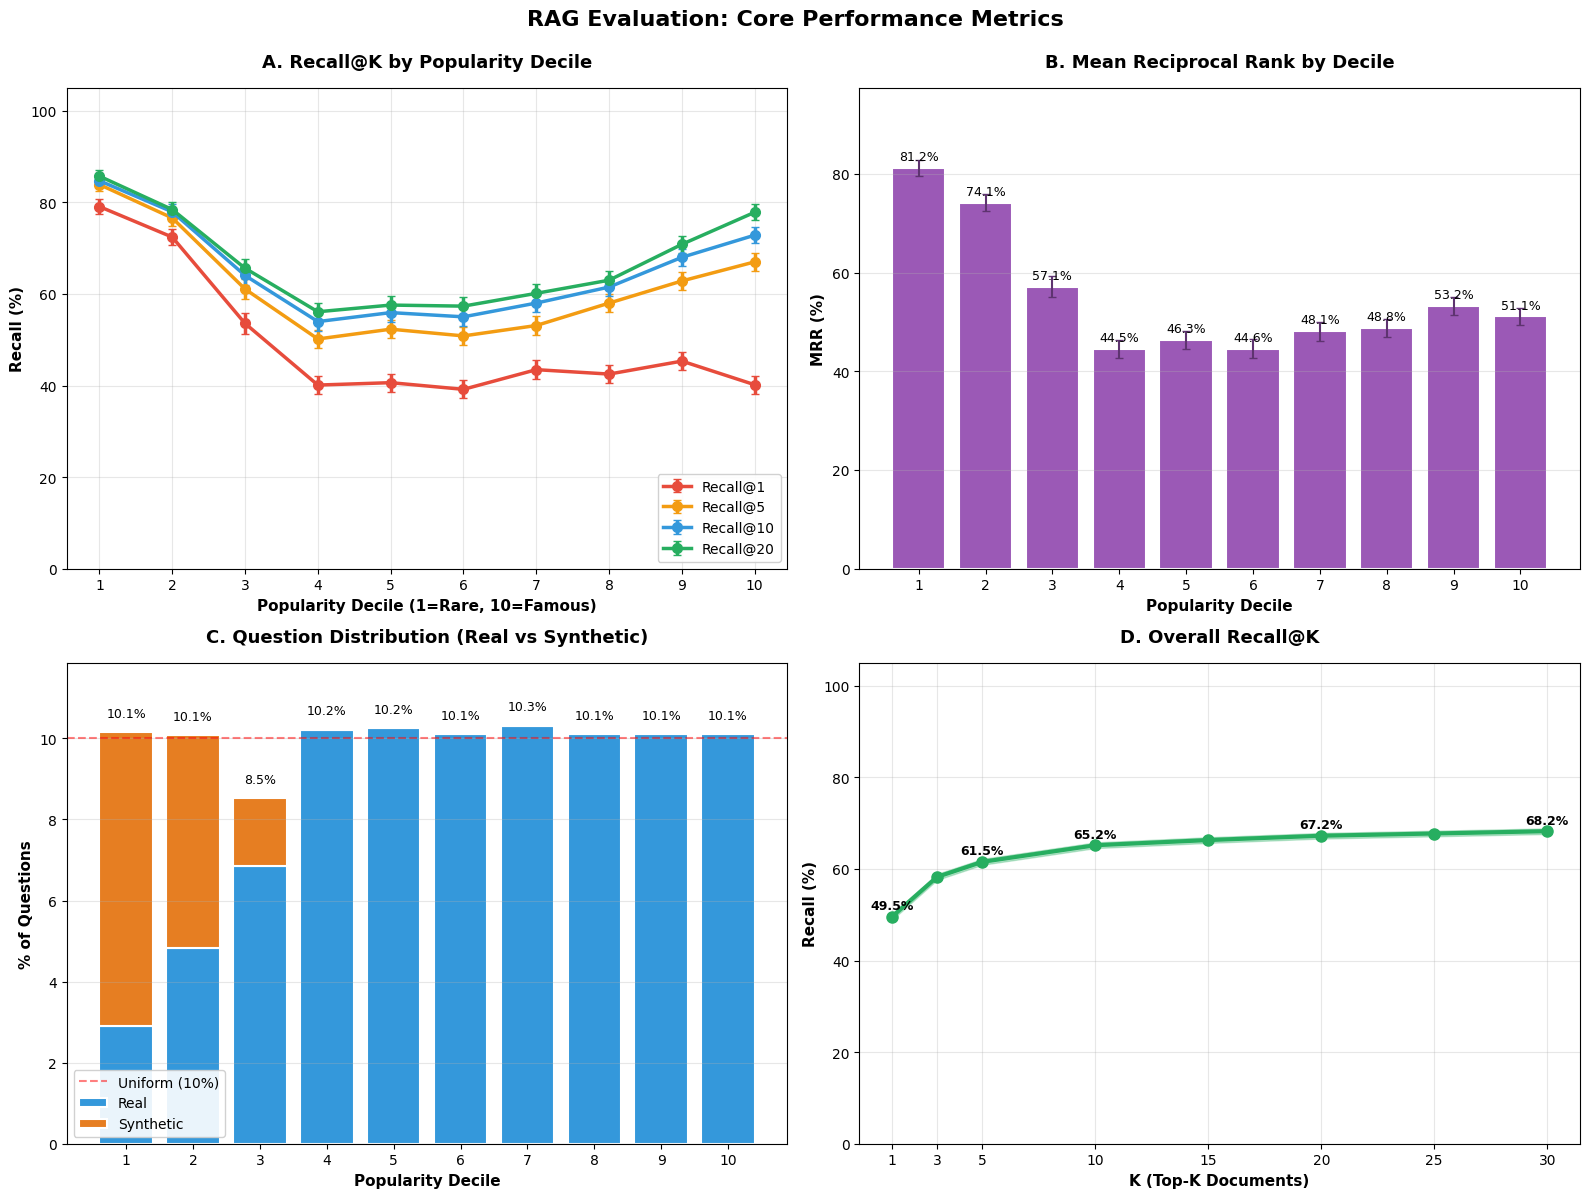

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precompute per-decile stats
pop_deciles = list(range(10))

def _recall_by_decile(k):
    recalls = []
    errs = []
    for d in pop_deciles:
        df = results_df[results_df["pop_decile"] == d]
        n = len(df)
        if n == 0:
            recalls.append(0)
            errs.append(0)
            continue
        p = ((df["found_at_rank"].notna()) & (df["found_at_rank"] <= k)).mean()
        se = np.sqrt(p * (1 - p) / n)
        recalls.append(p)
        errs.append(se)
    return np.array(recalls), np.array(errs)

def _mrr_by_decile():
    mrrs = []
    errs = []
    for d in pop_deciles:
        df = results_df[results_df["pop_decile"] == d]
        n = len(df)
        if n == 0:
            mrrs.append(0)
            errs.append(0)
            continue
        rr = df["found_at_rank"].apply(lambda x: 1 / x if pd.notna(x) else 0)
        mrr = rr.mean()
        se = rr.std(ddof=1) / np.sqrt(n) if n > 1 else 0
        mrrs.append(mrr)
        errs.append(se)
    return np.array(mrrs), np.array(errs)

# Panel 1: Recall@K Curves by Decile (with SE bars)
ax = axes[0, 0]
k_plot = [1, 5, 10, 20]
colors_k = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']

for k_idx, k in enumerate(k_plot):
    recalls, errs = _recall_by_decile(k)
    ax.errorbar(
        np.array(pop_deciles) + 1,
        recalls * 100,
        yerr=errs * 100,
        marker='o',
        linewidth=2.5,
        color=colors_k[k_idx],
        label=f'Recall@{k}',
        markersize=7,
        capsize=3,
    )

ax.set_xlabel("Popularity Decile (1=Rare, 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall (%)", fontsize=11, fontweight='bold')
ax.set_title("A. Recall@K by Popularity Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 105)

# Panel 2: MRR by Decile (with SE bars)
ax = axes[0, 1]
mrr_vals, mrr_errs = _mrr_by_decile()

bars = ax.bar(np.array(pop_deciles) + 1, mrr_vals * 100, color='#9b59b6', edgecolor='white', linewidth=1.5)
ax.errorbar(
    np.array(pop_deciles) + 1,
    mrr_vals * 100,
    yerr=mrr_errs * 100,
    fmt='none',
    ecolor='#5e3370',
    elinewidth=1.5,
    capsize=3,
)

for bar, val in zip(bars, mrr_vals * 100):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("MRR (%)", fontsize=11, fontweight='bold')
ax.set_title("B. Mean Reciprocal Rank by Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(max(mrr_vals * 100) * 1.2, 5))

# Panel 3: Question Distribution (All sources)
ax = axes[1, 0]
q_counts = results_df['pop_decile'].value_counts().sort_index()
q_pcts = (q_counts / len(results_df)) * 100

if "dataset" in results_df.columns:
    datasets = list(results_df["dataset"].dropna().unique())
    datasets.sort()
    bottoms = np.zeros(10)
    colors = plt.cm.tab10.colors

    for i, ds in enumerate(datasets):
        ds_counts = (
            results_df[results_df["dataset"] == ds]["pop_decile"]
            .value_counts()
            .reindex(range(10), fill_value=0)
        )
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(
            np.arange(1, 11),
            ds_pcts.values,
            bottom=bottoms,
            color=colors[i % len(colors)],
            edgecolor='white',
            linewidth=1.0,
            label=ds,
        )
        bottoms += ds_pcts.values

    for i, total in enumerate(bottoms):
        if total > 0.5:
            ax.text(i + 1, total + 0.3, f'{total:.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.legend(fontsize=9, framealpha=0.9, title="Dataset")
else:
    real_counts = []
    synth_counts = []
    for decile in range(10):
        decile_df = results_df[results_df['pop_decile'] == decile]
        if 'is_synthetic' in results_df.columns and len(decile_df) > 0:
            synth = (decile_df['is_synthetic'].sum() / len(results_df)) * 100
            real = ((~decile_df['is_synthetic']).sum() / len(results_df)) * 100
        else:
            synth = 0
            real = q_pcts.get(decile, 0)
        synth_counts.append(synth)
        real_counts.append(real)

    x_pos = np.arange(1, 11)
    ax.bar(x_pos, real_counts, color='#3498db', edgecolor='white', linewidth=1.5, label='Real')
    ax.bar(x_pos, synth_counts, bottom=real_counts, color='#e67e22',
           edgecolor='white', linewidth=1.5, label='Synthetic')

    for i, (r, s) in enumerate(zip(real_counts, synth_counts)):
        total = r + s
        if total > 0.5:
            ax.text(i + 1, total + 0.3, f'{total:.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.legend(fontsize=10, framealpha=0.9)

ax.axhline(10, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title("C. Question Distribution (All Sources)", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(q_pcts) * 1.15 if len(q_pcts) > 0 else 15)

# Panel 4: Overall Recall@K Curve (with SE band)
ax = axes[1, 1]
k_vals = [k for k in K_VALUES if k <= 30]
recall_vals = np.array([metrics[f'recall@{k}'] for k in k_vals])

n_total = len(results_df)
recall_errs = np.array([np.sqrt(p * (1 - p) / n_total) for p in recall_vals])

ax.plot(k_vals, recall_vals * 100, marker='o', linewidth=3, color='#27ae60', markersize=8)
ax.fill_between(k_vals, (recall_vals - recall_errs) * 100, (recall_vals + recall_errs) * 100, alpha=0.3, color='#27ae60')

for k in [1, 5, 10, 20, 30]:
    if k in k_vals:
        idx = k_vals.index(k)
        if recall_vals[idx] * 100 > 0.5:
            ax.text(k, recall_vals[idx] * 100 + 1, f'{recall_vals[idx] * 100:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel("K (Top-K Documents)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall (%)", fontsize=11, fontweight='bold')
ax.set_title("D. Overall Recall@K", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_vals)
ax.set_ylim(0, 105)

plt.suptitle("RAG Evaluation: Core Performance Metrics",
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Figure 1B: Recall@K by Dataset

Bar chart of Recall@$K$ (with standard error) for each dataset.

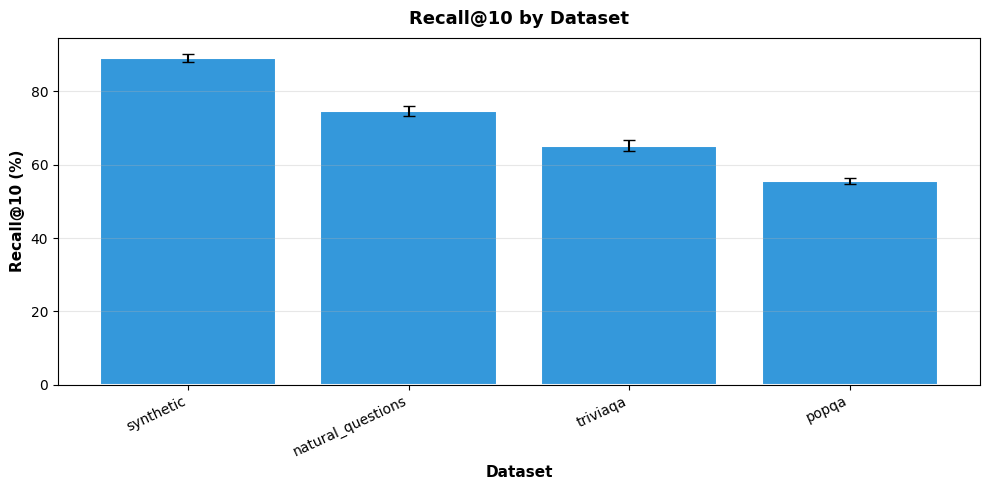

In [13]:
# Recall@K by dataset (with standard error)
if "dataset" in results_df.columns:
    dataset_stats = []
    for dataset, df in results_df.groupby("dataset"):
        n = len(df)
        if n == 0:
            continue
        p = ((df["found_at_rank"].notna()) & (df["found_at_rank"] <= TOP_K)).mean()
        se = np.sqrt(p * (1 - p) / n)
        dataset_stats.append({"dataset": dataset, "recall": p, "se": se, "n": n})

    ds_df = pd.DataFrame(dataset_stats).sort_values("recall", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ds_df["dataset"], ds_df["recall"] * 100, yerr=ds_df["se"] * 100,
           color="#3498db", edgecolor="white", linewidth=1.5, capsize=4)
    ax.set_ylabel(f"Recall@{TOP_K} (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=11, fontweight="bold")
    ax.set_title(f"Recall@{TOP_K} by Dataset", fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'dataset' column found in results_df.")

### Figure 2: Popularity Bias Analysis

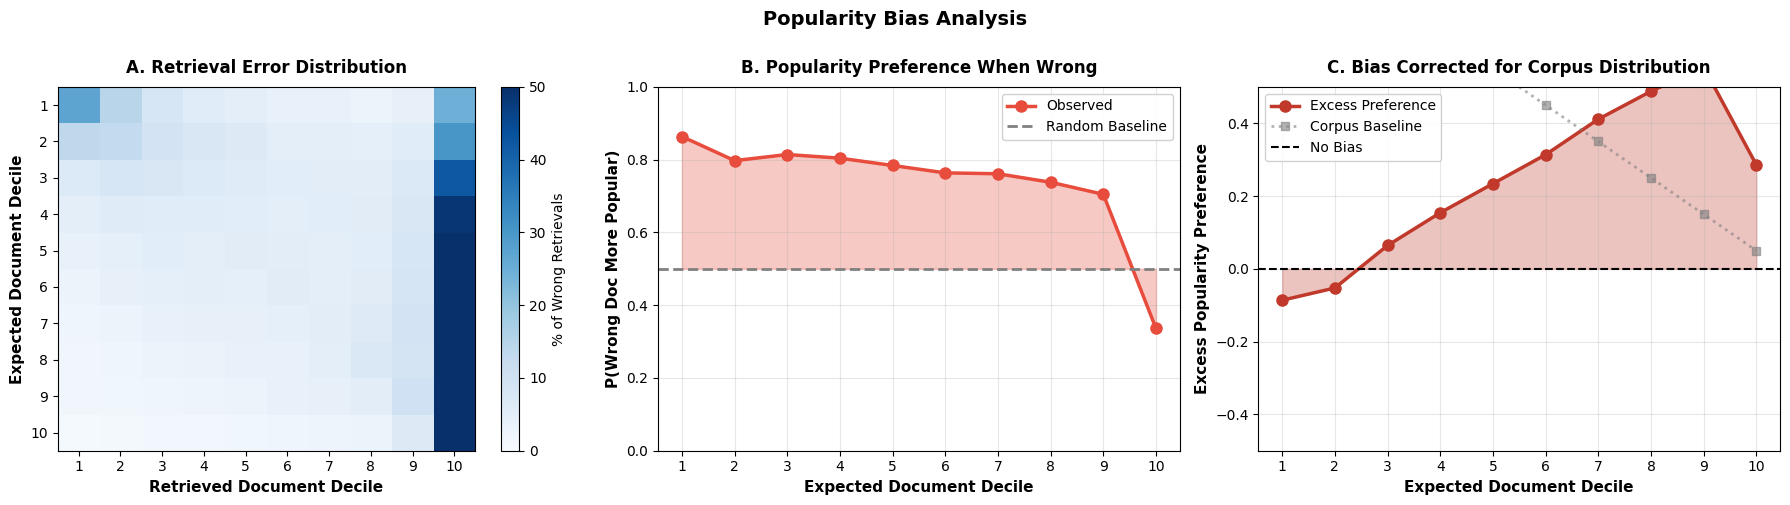

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Bias Heatmap
ax = axes[0]
heatmap_data = np.zeros((10, 10))

for _, row in results_df.iterrows():
    expected_dec = int(row['pop_decile'])
    wrong_pops = row['wrong_docs_popularities']
    if wrong_pops:
        for wp in wrong_pops:
            wrong_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(wrong_dec):
                heatmap_data[expected_dec, int(wrong_dec)] += 1

row_sums = heatmap_data.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_pct = heatmap_data / row_sums * 100

im = ax.imshow(heatmap_pct, cmap='Blues', aspect='auto', vmin=0, vmax=50)
plt.colorbar(im, ax=ax, label='% of Wrong Retrievals')
ax.set_xlabel("Retrieved Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_title("A. Retrieval Error Distribution", fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(1, 11))
ax.set_yticklabels(range(1, 11))

# Panel 2: Popularity Preference
ax = axes[1]
bias_frac_by_decile = []

for d in range(10):
    subset = results_df[results_df["pop_decile"] == d]
    num_higher = 0
    num_total = 0
    
    for wp_list, pop in zip(subset["wrong_docs_popularities"], subset["popularity"]):
        if not wp_list:
            continue
        for wp in wp_list:
            num_total += 1
            if wp > pop:
                num_higher += 1
    
    bias_frac_by_decile.append(num_higher / num_total if num_total > 0 else np.nan)

ax.plot(range(1, 11), bias_frac_by_decile, marker="o", linewidth=2.5, 
        color='#e74c3c', markersize=8, label="Observed")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=2, label="Random Baseline")
ax.fill_between(range(1, 11), bias_frac_by_decile, 0.5, alpha=0.3, color='#e74c3c')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("P(Wrong Doc More Popular)", fontsize=11, fontweight='bold')
ax.set_title("B. Popularity Preference When Wrong", fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(0, 1)
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

# Panel 3: Excess Preference
ax = axes[2]
baseline_by_decile = [(9 - d + 0.5) / 10 for d in range(10)]
excess_preference = [obs - exp if not np.isnan(obs) else np.nan 
                    for obs, exp in zip(bias_frac_by_decile, baseline_by_decile)]

ax.plot(range(1, 11), excess_preference, marker="o", color="#c0392b", 
        linewidth=2.5, markersize=8, label="Excess Preference")
ax.plot(range(1, 11), baseline_by_decile, marker="s", linestyle=":", 
        color="gray", alpha=0.6, linewidth=2, label="Corpus Baseline")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5, label="No Bias")
ax.fill_between(range(1, 11), excess_preference, 0, alpha=0.3, color='#c0392b')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Excess Popularity Preference", fontsize=11, fontweight='bold')
ax.set_title("C. Bias Corrected for Corpus Distribution", fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(-0.5, 0.5)
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

plt.suptitle("Popularity Bias Analysis", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Figure 3: Detailed Decile Analysis

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_75718/4271215982.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correct_pcts = results_df.groupby('pop_decile').apply(


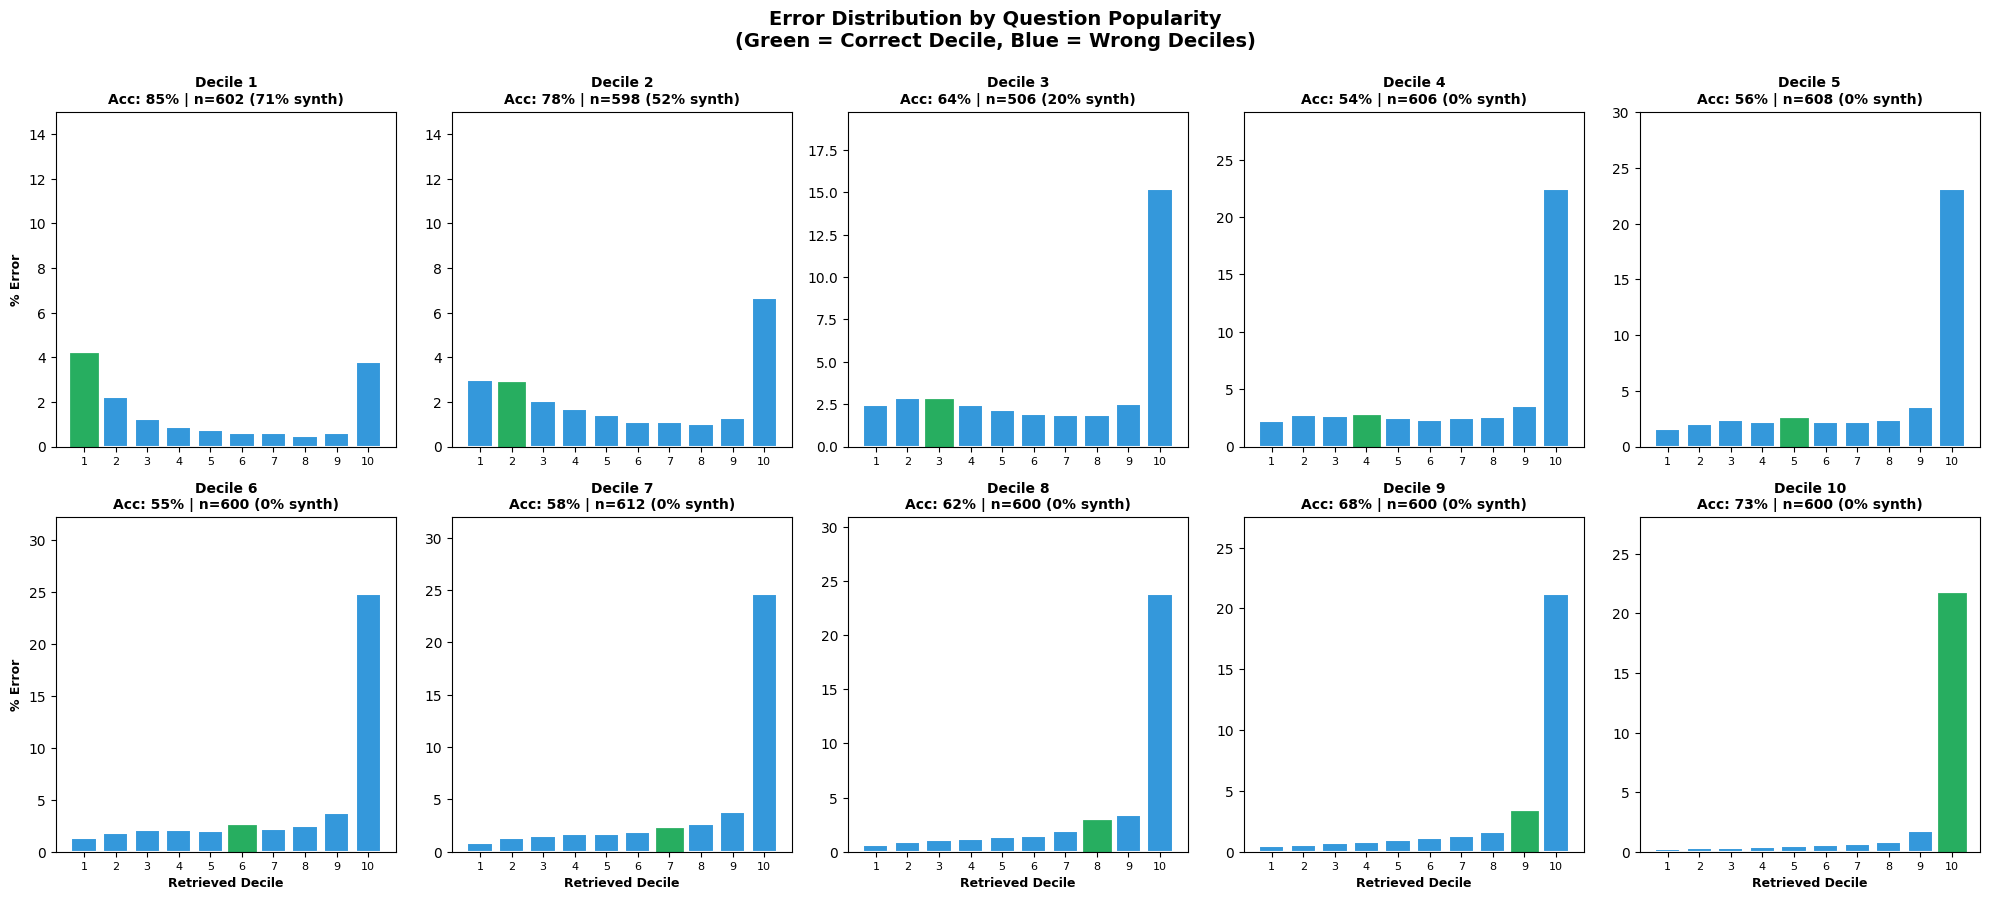

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

correct_pcts = results_df.groupby('pop_decile').apply(
    lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean() * 100
).reindex(range(10), fill_value=0)

for decile in range(10):
    ax = axes[decile]
    subset = results_df[results_df['pop_decile'] == decile]
    
    if len(subset) < 3:
        ax.text(0.5, 0.5, f"Insufficient Data\n(n={len(subset)})", 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.set_title(f"Decile {decile+1}", fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    wrong_counts = np.zeros(10)
    total_wrong = 0
    for _, row in subset.iterrows():
        for wp in (row['wrong_docs_popularities'] or []):
            w_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(w_dec):
                wrong_counts[int(w_dec)] += 1
                total_wrong += 1
    
    if total_wrong > 0:
        raw = (wrong_counts / total_wrong) * 100
        scaled = raw * ((100 - correct_pcts[decile]) / 100)
    else:
        scaled = np.zeros(10)
    
    bars = ax.bar(range(10), scaled, color='#3498db', edgecolor='white', linewidth=1.5, width=0.8)
    bars[decile].set_color('#27ae60')
    bars[decile].set_linewidth(2)
    
    n_synth = int(subset.get('is_synthetic', pd.Series([False]*len(subset))).sum())
    synth_pct = n_synth / len(subset) * 100 if len(subset) > 0 else 0
    
    ax.set_title(f"Decile {decile+1}\nAcc: {correct_pcts[decile]:.0f}% | n={len(subset)} ({synth_pct:.0f}% synth)", 
                fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(15, scaled.max() * 1.3) if scaled.max() > 0 else 15)
    ax.set_xticks(range(10))
    ax.set_xticklabels(range(1, 11), fontsize=8)
    
    if decile % 5 == 0:
        ax.set_ylabel("% Error", fontsize=9, fontweight='bold')
    if decile >= 5:
        ax.set_xlabel("Retrieved Decile", fontsize=9, fontweight='bold')

plt.suptitle("Error Distribution by Question Popularity\n(Green = Correct Decile, Blue = Wrong Deciles)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7️⃣ Summary

In [12]:
print("\n" + "="*70)
print("✨ EVALUATION SUMMARY")
print("="*70)

print(f"\n📊 Dataset: {len(results_df):,} questions")
print(f"   Top K: {TOP_K}")
print(f"   Overall Recall@{TOP_K}: {metrics[f'recall@{TOP_K}']:.2%}")
print(f"   MRR: {metrics['mrr']:.4f}")

if 'is_synthetic' in results_df.columns:
    n_synth = int(results_df['is_synthetic'].sum())
    print(f"\n🤖 Synthetic Questions: {n_synth:,} ({n_synth/len(results_df)*100:.1f}%)")
    if 'recall_by_synthetic' in metrics:
        print(f"   Real Recall@{TOP_K}: {metrics['recall_by_synthetic'].get(False, 0):.2%}")
        print(f"   Synthetic Recall@{TOP_K}: {metrics['recall_by_synthetic'].get(True, 0):.2%}")

if len(decile_metrics) > 0:
    print(f"\n📈 Decile Performance Range:")
    best_decile = decile_metrics.loc[decile_metrics['recall@10'].idxmax()]
    worst_decile = decile_metrics.loc[decile_metrics['recall@10'].idxmin()]
    print(f"   Best:  Decile {int(best_decile['decile'])} - {best_decile['recall@10']:.2%} recall")
    print(f"   Worst: Decile {int(worst_decile['decile'])} - {worst_decile['recall@10']:.2%} recall")
    print(f"   Gap: {(best_decile['recall@10'] - worst_decile['recall@10']):.2%}")

found_df = results_df[results_df['found_at_rank'].notna()]
if len(found_df) > 10:
    correlation, p_value = stats.spearmanr(found_df["popularity"], found_df["found_at_rank"])
    print(f"\n📊 Popularity-Rank Correlation:")
    print(f"   Spearman ρ: {correlation:.4f} (p={p_value:.4f})")
    print(f"   {'Significant' if p_value < 0.05 else 'Not significant'} relationship")

print("\n" + "="*70)
print("✓ Evaluation complete")
print("="*70)


✨ EVALUATION SUMMARY

📊 Dataset: 5,932 questions
   Top K: 10
   Overall Recall@10: 65.17%
   MRR: 0.5483

🤖 Synthetic Questions: 840 (14.2%)
   Real Recall@10: 61.23%
   Synthetic Recall@10: 89.05%

📈 Decile Performance Range:
   Best:  Decile 1 - 84.72% recall
   Worst: Decile 4 - 53.96% recall
   Gap: 30.76%

📊 Popularity-Rank Correlation:
   Spearman ρ: 0.2779 (p=0.0000)
   Significant relationship

✓ Evaluation complete
